In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
os.makedirs('results', exist_ok=True)

path = kagglehub.dataset_download("yasserh/wine-quality-dataset")

wine_path = os.path.join(path, "WineQT.csv")
wine_df = pd.read_csv(wine_path)

wine_df['quality_binary'] = wine_df['quality'].apply(lambda x: 1 if x >= 7 else 0)

wine_df.head()

Using Colab cache for faster access to the 'wine-quality-dataset' dataset.


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id,quality_binary
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4,0


quality_binary
0    0.860892
1    0.139108
Name: proportion, dtype: float64


/tmp/ipykernel_11045/1518287659.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality_binary', data=wine_df, palette='Blues')


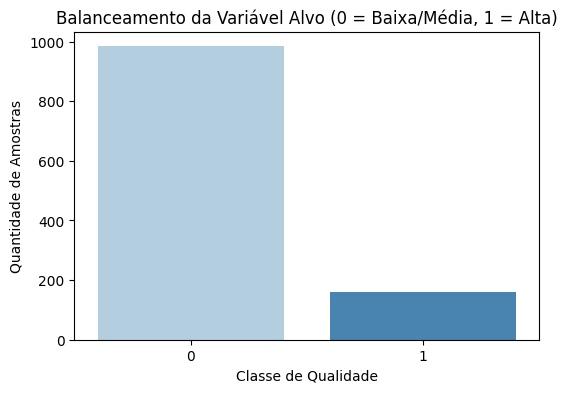

In [3]:
print(wine_df['quality_binary'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='quality_binary', data=wine_df, palette='Blues')
plt.title('Balanceamento da Variável Alvo (0 = Baixa/Média, 1 = Alta)')
plt.xlabel('Classe de Qualidade')
plt.ylabel('Quantidade de Amostras')
plt.savefig('results/balanceamento_classes.png', bbox_inches='tight')
plt.show()

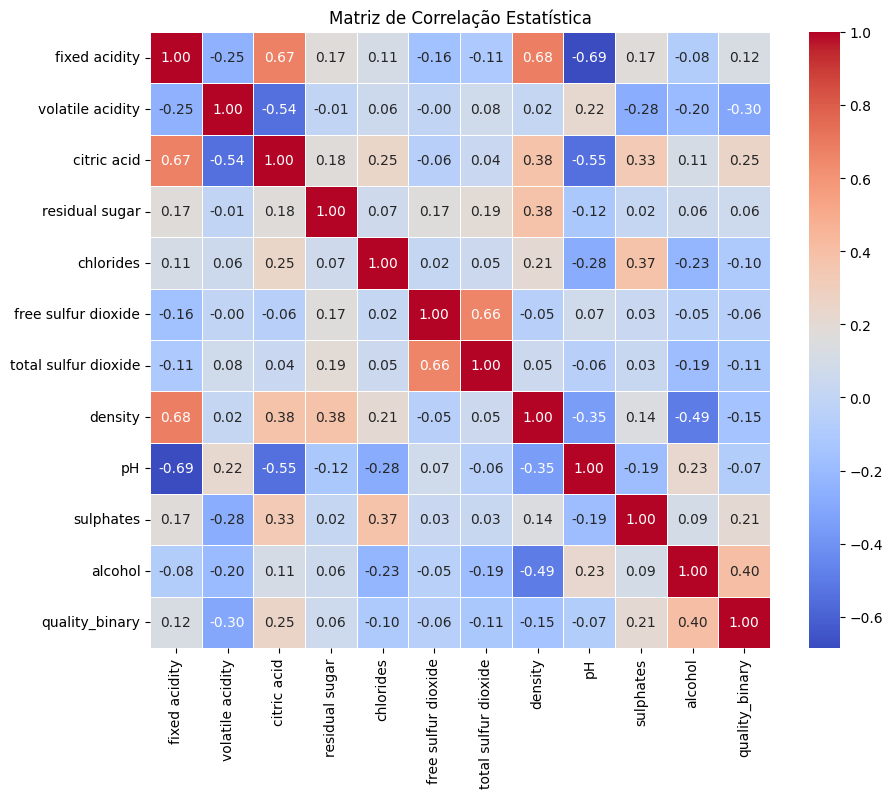

In [4]:
plt.figure(figsize=(10, 8))

corr_matrix = wine_df.drop(['Id', 'quality'], axis=1).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação Estatística')
plt.savefig('results/matriz_correlacao.png', bbox_inches='tight')
plt.show()

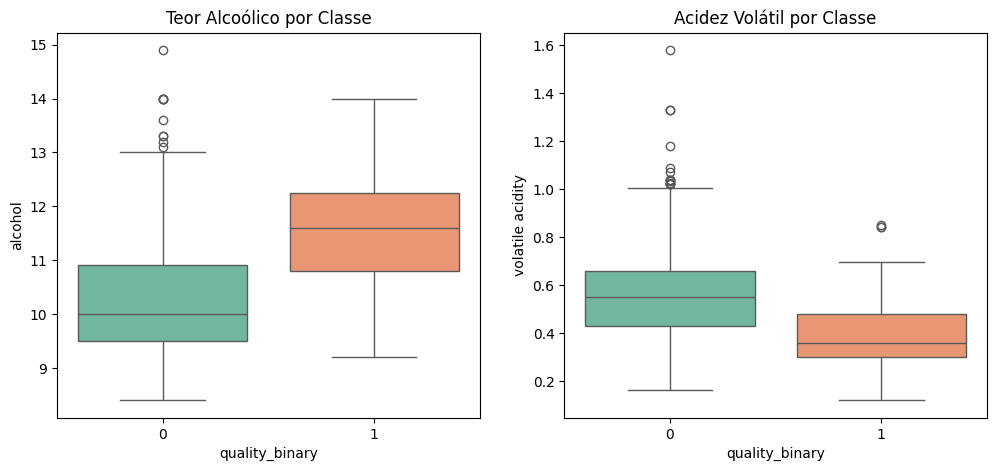

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='quality_binary', y='alcohol', hue='quality_binary', data=wine_df, ax=axes[0], palette='Set2', legend=False)
axes[0].set_title('Teor Alcoólico por Classe')

sns.boxplot(x='quality_binary', y='volatile acidity', hue='quality_binary', data=wine_df, ax=axes[1], palette='Set2', legend=False)
axes[1].set_title('Acidez Volátil por Classe')

plt.savefig('results/distribuicao_features.png', bbox_inches='tight')
plt.show()

In [7]:
y = wine_df['quality_binary']
x = wine_df.drop(['quality', 'quality_binary', 'Id'], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=6)

print(f"Amostras de Treino: {x_train.shape[0]}")
print(f"Amostras de Teste: {x_test.shape[0]}")

Amostras de Treino: 800
Amostras de Teste: 343


In [8]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [9]:
logistic_model = LogisticRegression(random_state=6, solver='liblinear')
logistic_model.fit(x_train_scaled, y_train)
y_pred_logistic = logistic_model.predict(x_test_scaled)

random_forest_model = RandomForestClassifier(random_state=6)
random_forest_model.fit(x_train_scaled, y_train)
y_pred_forest = random_forest_model.predict(x_test_scaled)

Acurácia: 0.88
                 precision    recall  f1-score   support

Baixa/Média (0)       0.91      0.96      0.93       299
       Alta (1)       0.57      0.39      0.46        44

       accuracy                           0.88       343
      macro avg       0.74      0.67      0.70       343
   weighted avg       0.87      0.88      0.87       343



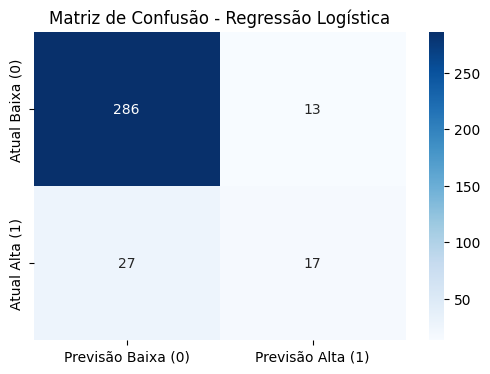

In [10]:
print(f"Acurácia: {round(accuracy_score(y_test, y_pred_logistic), 2)}")
print(classification_report(y_test, y_pred_logistic, target_names=['Baixa/Média (0)', 'Alta (1)']))

plt.figure(figsize=(6, 4))
conf_matrix_log = confusion_matrix(y_test, y_pred_logistic)
sns.heatmap(conf_matrix_log, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Previsão Baixa (0)', 'Previsão Alta (1)'],
            yticklabels=['Atual Baixa (0)', 'Atual Alta (1)'])
plt.title('Matriz de Confusão - Regressão Logística')
plt.savefig('results/matriz_confusao_logistica.png', bbox_inches='tight')
plt.show()

In [ ]:
print(f"Acurácia: {round(accuracy_score(y_test, y_pred_forest), 2)}")
print(classification_report(y_test, y_pred_forest, target_names=['Baixa/Média (0)', 'Alta (1)']))

plt.figure(figsize=(6, 4))
conf_matrix_forest = confusion_matrix(y_test, y_pred_forest)
sns.heatmap(conf_matrix_forest, annot=True, cmap='Blues', fmt='d',
            xticklabels=['Previsão Baixa (0)', 'Previsão Alta (1)'],
            yticklabels=['Atual Baixa (0)', 'Atual Alta (1)'])
plt.title('Matriz de Confusão - Random Forest')
plt.savefig('results/matriz_confusao_random_forest.png', bbox_inches='tight')
plt.show()